In [1]:
import pandas as pd
from prophet import Prophet
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print("all good")

C:\Users\Hhasa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


all good


In [2]:
import os

raw = '../data/raw/'

# Check files are there
print(os.listdir(raw))

['articles.csv.zip', 'transactions_train.csv.zip']


In [7]:
import zipfile
import os

raw = '../data/raw/'

# Unzip transactions
with zipfile.ZipFile(raw + 'transactions_train.csv.zip', 'r') as z:
    z.extractall(raw)
    print("Transactions unzipped")

# Unzip articles
with zipfile.ZipFile(raw + 'articles.csv.zip', 'r') as z:
    z.extractall(raw)
    print("Articles unzipped")

print(os.listdir(raw))

Transactions unzipped
Articles unzipped
['articles.csv', 'articles.csv.zip', 'transactions_train.csv', 'transactions_train.csv.zip']


In [8]:
# Load transactions (500k sample)
tx = pd.read_csv('../data/raw/transactions_train.csv', 
                 nrows=500000,
                 usecols=['t_dat', 'customer_id', 'article_id', 'price'],
                 parse_dates=['t_dat'])

# Load articles (full, it's small)
articles = pd.read_csv('../data/raw/articles.csv')

print("Transactions shape:", tx.shape)
print("Articles shape:", articles.shape)
print()
print(tx.head())
print()
print(articles.columns.tolist())

Transactions shape: (500000, 4)
Articles shape: (105542, 25)

       t_dat                                        customer_id  article_id  \
0 2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   663713001   
1 2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   541518023   
2 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   505221004   
3 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   685687003   
4 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...   685687004   

      price  
0  0.050831  
1  0.030492  
2  0.015237  
3  0.016932  
4  0.016932  

['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'i

In [9]:
# Merge transactions with article metadata
df = tx.merge(
    articles[['article_id', 'product_type_name', 'product_group_name', 
              'department_name', 'index_group_name', 'garment_group_name']],
    on='article_id',
    how='left'
)

print("Merged shape:", df.shape)
print()

# See what product groups exist and how many transactions each has
print("Top product groups:")
print(df['product_group_name'].value_counts().head(20))

Merged shape: (500000, 9)

Top product groups:
product_group_name
Garment Upper body     248520
Garment Lower body     117566
Underwear               31918
Garment Full body       31431
Accessories             26045
Socks & Tights          14954
Shoes                   12325
Swimwear                11193
Nightwear                5600
Unknown                   256
Cosmetic                   76
Items                      73
Underwear/nightwear        40
Interior textile            2
Bags                        1
Name: count, dtype: int64


In [10]:
# Look at product types within Upper and Lower body
print("Upper body types:")
print(df[df['product_group_name'] == 'Garment Upper body']['product_type_name'].value_counts().head(15))

print()
print("Lower body types:")
print(df[df['product_group_name'] == 'Garment Lower body']['product_type_name'].value_counts().head(15))

print()
print("Full body types:")
print(df[df['product_group_name'] == 'Garment Full body']['product_type_name'].value_counts().head(10))

print()
print("Swimwear types:")
print(df[df['product_group_name'] == 'Swimwear']['product_type_name'].value_counts().head(10))

Upper body types:
product_type_name
Sweater               92150
T-shirt               31795
Blouse                24706
Top                   19982
Shirt                 15523
Hoodie                13495
Vest top              13168
Jacket                12961
Cardigan               9835
Blazer                 7000
Coat                   4269
Bodysuit               1723
Polo shirt             1426
Outdoor Waistcoat       293
Tailored Waistcoat      194
Name: count, dtype: int64

Lower body types:
product_type_name
Trousers            85337
Leggings/Tights     15286
Skirt               12111
Shorts               4713
Outdoor trousers      119
Name: count, dtype: int64

Full body types:
product_type_name
Dress                27863
Jumpsuit/Playsuit     1611
Garment Set           1176
Dungarees              591
Costumes               126
Outdoor overall         64
Name: count, dtype: int64

Swimwear types:
product_type_name
Swimwear bottom    4664
Bikini top         4272
Swimsuit          

In [11]:
# Define categories
categories = {
    'Trousers': ('product_type_name', 'Trousers'),
    'T-shirt':  ('product_type_name', 'T-shirt'),
    'Sweater':  ('product_type_name', 'Sweater'),
    'Swimwear': ('product_group_name', 'Swimwear')
}

# Build weekly series for each
weekly_series = {}

for name, (col, val) in categories.items():
    series = (
        df[df[col] == val]
        .groupby(pd.Grouper(key='t_dat', freq='W'))
        .size()
        .reset_index(name='y')
        .rename(columns={'t_dat': 'ds'})
    )
    weekly_series[name] = series
    print(f"{name}: {len(series)} weeks, avg {series['y'].mean():.0f} transactions/week")

print("\nAll series built successfully")

Trousers: 2 weeks, avg 42668 transactions/week
T-shirt: 2 weeks, avg 15898 transactions/week
Sweater: 2 weeks, avg 46075 transactions/week
Swimwear: 2 weeks, avg 5596 transactions/week

All series built successfully


In [21]:
import matplotlib.pyplot as plt

# Re-merge with full data
df = tx.merge(
    articles[['article_id', 'product_type_name', 'product_group_name', 
              'department_name', 'index_group_name', 'garment_group_name']],
    on='article_id',
    how='left'
)

# Rebuild weekly series
weekly_series = {}

for name, (col, val) in categories.items():
    series = (
        df[df[col] == val]
        .groupby(pd.Grouper(key='t_dat', freq='W'))
        .size()
        .reset_index(name='y')
        .rename(columns={'t_dat': 'ds'})
    )
    weekly_series[name] = series
    print(f"{name}: {len(series)} weeks, avg {series['y'].mean():.0f} transactions/week")

Trousers: 106 weeks, avg 39783 transactions/week
T-shirt: 106 weeks, avg 20790 transactions/week
Sweater: 106 weeks, avg 26257 transactions/week
Swimwear: 106 weeks, avg 24332 transactions/week


In [15]:
for name, series in weekly_series.items():
    print(f"{name}: {series['ds'].min()} to {series['ds'].max()}")

Trousers: 2018-09-23 00:00:00 to 2018-09-30 00:00:00
T-shirt: 2018-09-23 00:00:00 to 2018-09-30 00:00:00
Sweater: 2018-09-23 00:00:00 to 2018-09-30 00:00:00
Swimwear: 2018-09-23 00:00:00 to 2018-09-30 00:00:00


In [20]:
tx = pd.read_csv('../data/raw/transactions_train.csv', 
                 usecols=['t_dat', 'customer_id', 'article_id', 'price'],
                 parse_dates=['t_dat'])

print("Shape:", tx.shape)
print("Date range:", tx['t_dat'].min(), "to", tx['t_dat'].max())

Shape: (31788324, 4)
Date range: 2018-09-20 00:00:00 to 2020-09-22 00:00:00


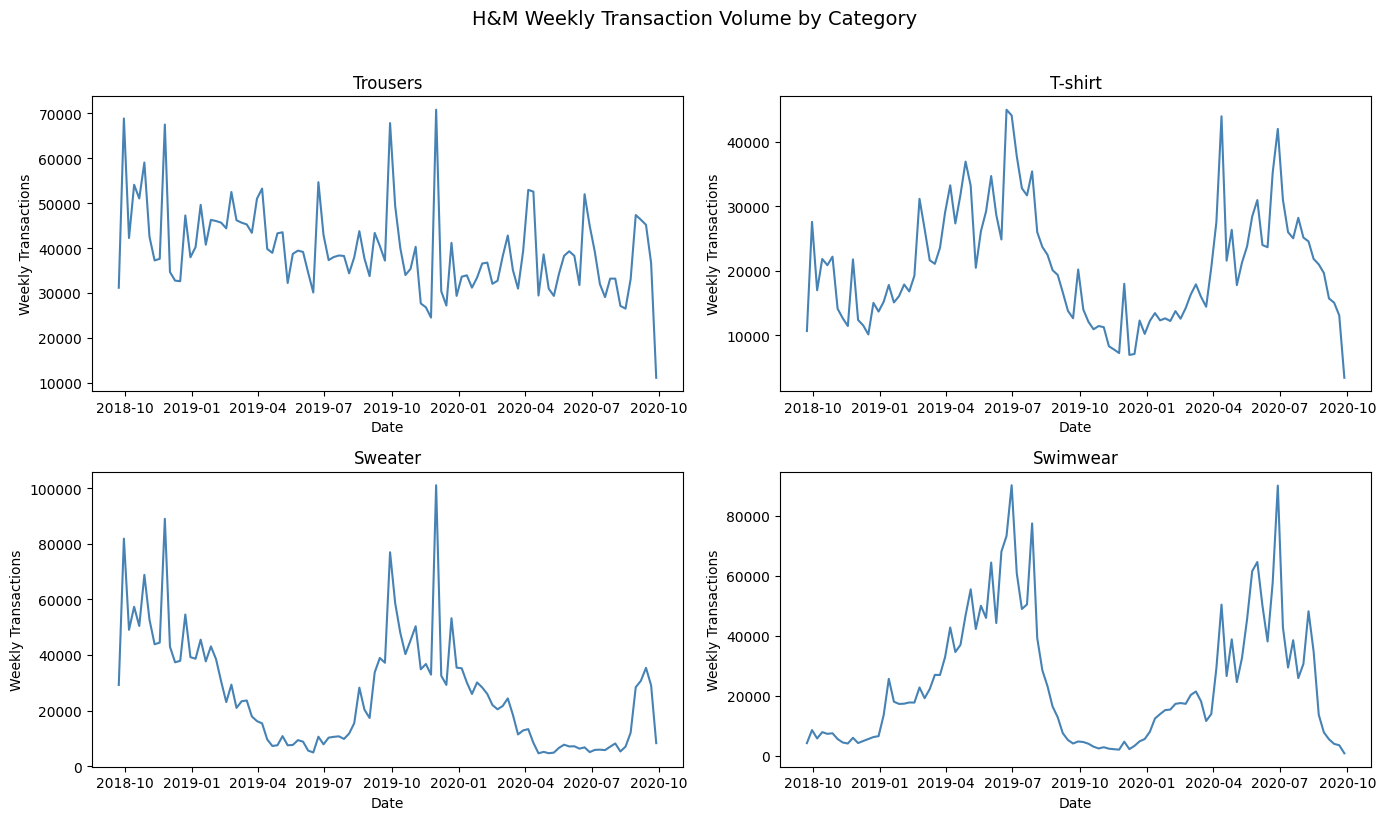

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (name, series) in enumerate(weekly_series.items()):
    axes[i].plot(series['ds'], series['y'], color='steelblue', linewidth=1.5)
    axes[i].set_title(name)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Weekly Transactions')

plt.suptitle('H&M Weekly Transaction Volume by Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/eda_raw_series.png')
plt.show()

In [23]:
for name, series in weekly_series.items():
    missing = series['y'].isna().sum()
    zero_weeks = (series['y'] == 0).sum()
    print(f"{name}: {missing} missing weeks, {zero_weeks} zero-sales weeks")

Trousers: 0 missing weeks, 0 zero-sales weeks
T-shirt: 0 missing weeks, 0 zero-sales weeks
Sweater: 0 missing weeks, 0 zero-sales weeks
Swimwear: 0 missing weeks, 0 zero-sales weeks


In [24]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

models = {}
forecasts = {}

for name, series in weekly_series.items():
    print(f"Fitting {name}...")
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    
    model.fit(series)
    
    future = model.make_future_dataframe(periods=12, freq='W')
    forecast = model.predict(future)
    
    models[name] = model
    forecasts[name] = forecast
    print(f"  Done. Forecast runs to {forecast['ds'].max().date()}")

print("\nAll models fitted successfully")

Fitting Trousers...


15:46:48 - cmdstanpy - INFO - Chain [1] start processing
15:46:49 - cmdstanpy - INFO - Chain [1] done processing
15:46:50 - cmdstanpy - INFO - Chain [1] start processing


  Done. Forecast runs to 2020-12-20
Fitting T-shirt...


15:46:50 - cmdstanpy - INFO - Chain [1] done processing
15:46:50 - cmdstanpy - INFO - Chain [1] start processing


  Done. Forecast runs to 2020-12-20
Fitting Sweater...


15:46:50 - cmdstanpy - INFO - Chain [1] done processing
15:46:50 - cmdstanpy - INFO - Chain [1] start processing


  Done. Forecast runs to 2020-12-20
Fitting Swimwear...


15:46:50 - cmdstanpy - INFO - Chain [1] done processing


  Done. Forecast runs to 2020-12-20

All models fitted successfully


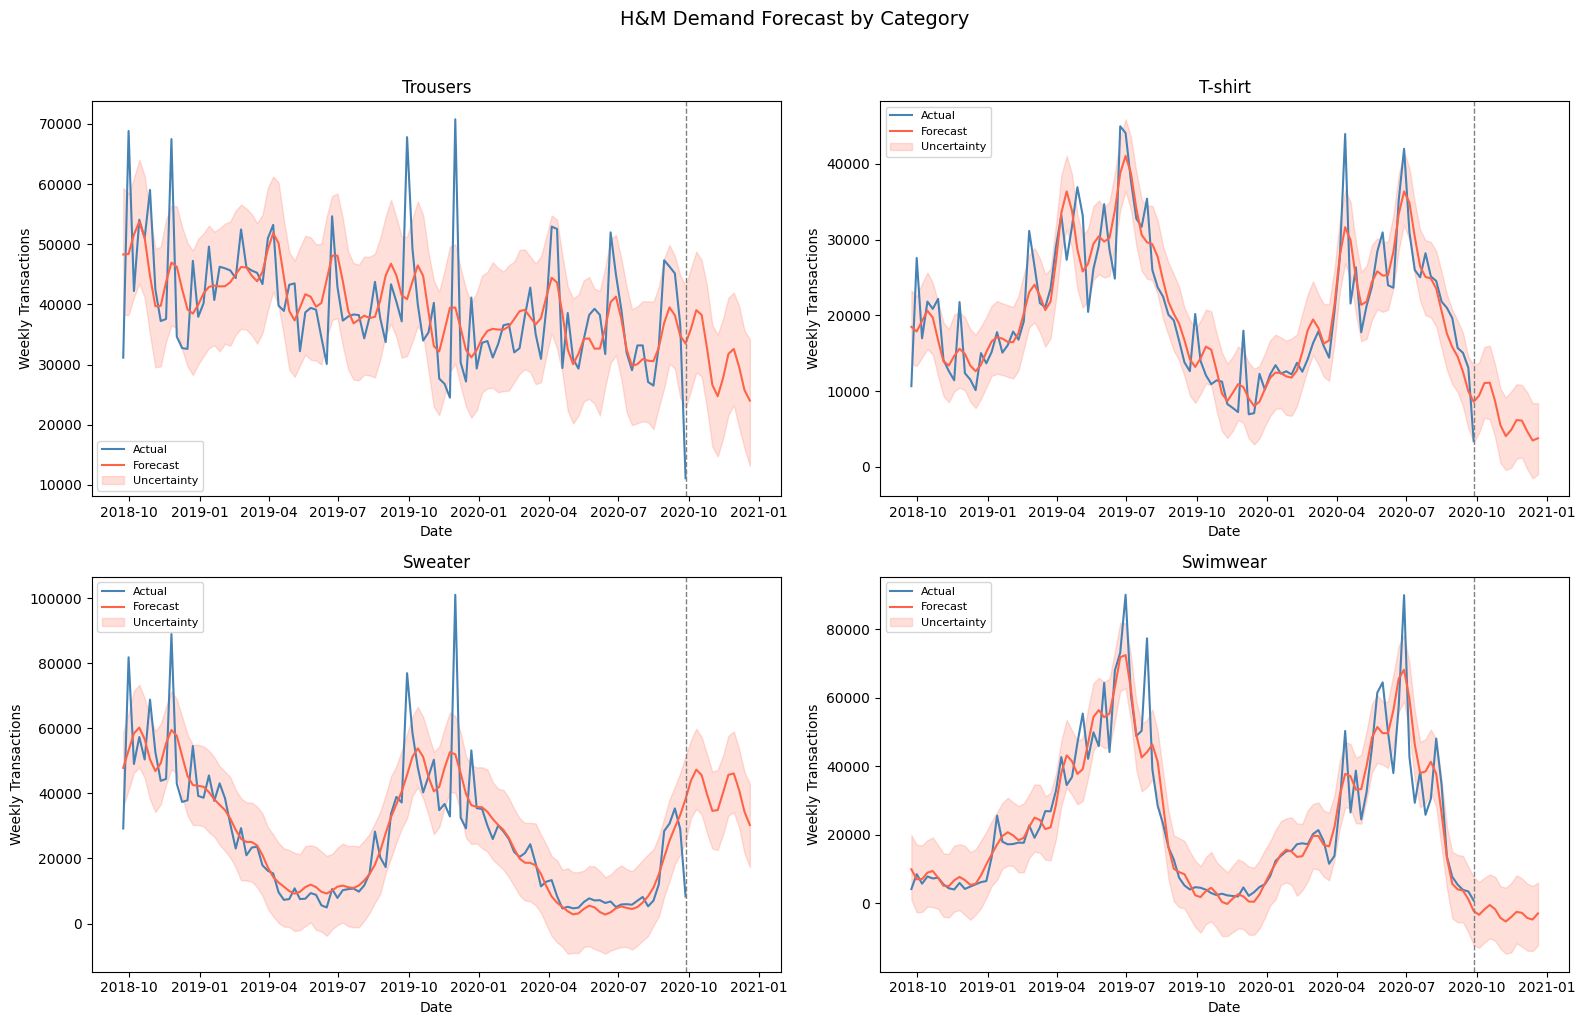

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    forecast = forecasts[name]
    series = weekly_series[name]
    
    # Plot forecast
    axes[i].plot(series['ds'], series['y'], 
                 color='steelblue', linewidth=1.5, label='Actual')
    axes[i].plot(forecast['ds'], forecast['yhat'], 
                 color='tomato', linewidth=1.5, label='Forecast')
    axes[i].fill_between(forecast['ds'], 
                          forecast['yhat_lower'], 
                          forecast['yhat_upper'],
                          color='tomato', alpha=0.2, label='Uncertainty')
    
    # Mark where forecast starts
    axes[i].axvline(x=series['ds'].max(), 
                    color='gray', linestyle='--', linewidth=1)
    
    axes[i].set_title(name)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Weekly Transactions')
    axes[i].legend(fontsize=8)

plt.suptitle('H&M Demand Forecast by Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/forecast_all_categories.png')
plt.show()

In [26]:
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
import numpy as np

# ── Sweater Tuning ────────────────────────────────────────────────────────────
#
# TUNING RATIONALE
# ----------------
# Sweater has the sharpest seasonal pattern of all four categories —
# demand spikes aggressively in September-October and collapses in spring.
# The default changepoint_prior_scale=0.05 is deliberately conservative
# to avoid overfitting noise, but for Sweater this smooths over the
# sharp October changepoint and underestimates peak demand.
#
# We test three parameters:
#
# changepoint_prior_scale : controls trend flexibility
#   0.05 (default) -> smooth trend, misses sharp transitions
#   0.1            -> moderate flexibility
#   0.3            -> aggressive, follows data closely
#
# fourier_order : controls complexity of the seasonality curve
#   10 (default)   -> standard yearly seasonality
#   15             -> more complex, can capture sharper peaks
#   20             -> maximum complexity, risk of overfitting
#
# n_changepoints : number of potential changepoint locations Prophet
#                  considers. Default is 25. Increasing gives more
#                  opportunities to detect the sharp Oct transition.
#
# EVALUATION
# ----------
# We use WMAPE as the primary metric (same as main model) so results
# are directly comparable. We test on in-sample fit — a proper
# holdout evaluation would require splitting the 2-year dataset,
# noted as a future improvement.

sweater_series = weekly_series['Sweater']

param_grid = [
    {'changepoint_prior_scale': 0.05, 'fourier_order': 10, 'n_changepoints': 25},  # baseline
    {'changepoint_prior_scale': 0.10, 'fourier_order': 10, 'n_changepoints': 25},
    {'changepoint_prior_scale': 0.20, 'fourier_order': 10, 'n_changepoints': 25},
    {'changepoint_prior_scale': 0.30, 'fourier_order': 10, 'n_changepoints': 25},
    {'changepoint_prior_scale': 0.10, 'fourier_order': 15, 'n_changepoints': 25},
    {'changepoint_prior_scale': 0.20, 'fourier_order': 15, 'n_changepoints': 35},
    {'changepoint_prior_scale': 0.30, 'fourier_order': 15, 'n_changepoints': 35},
    {'changepoint_prior_scale': 0.10, 'fourier_order': 20, 'n_changepoints': 35},
]

tuning_results = []

for params in param_grid:
    model = Prophet(
        yearly_seasonality=params['fourier_order'],
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        n_changepoints=params['n_changepoints'],
        interval_width=0.80
    )
    model.fit(sweater_series)
    
    future   = model.make_future_dataframe(periods=12, freq='W')
    forecast = model.predict(future)
    
    actual    = sweater_series['y'].values
    predicted = forecast.loc[forecast['ds'].isin(sweater_series['ds']), 'yhat'].values
    wmape     = np.sum(np.abs(actual - predicted)) / np.sum(actual) * 100
    
    tuning_results.append({**params, 'wmape': round(wmape, 2)})
    print(f"cps={params['changepoint_prior_scale']} | "
          f"fourier={params['fourier_order']} | "
          f"n_cp={params['n_changepoints']} | "
          f"WMAPE={round(wmape, 2)}%")

# Best params
best = min(tuning_results, key=lambda x: x['wmape'])
print(f"\nBest params: {best}")
print(f"Improvement: 21.3% -> {best['wmape']}%")

18:12:39 - cmdstanpy - INFO - Chain [1] start processing
18:12:41 - cmdstanpy - INFO - Chain [1] done processing


cps=0.05 | fourier=10 | n_cp=25 | WMAPE=22.26%


18:12:42 - cmdstanpy - INFO - Chain [1] start processing
18:12:42 - cmdstanpy - INFO - Chain [1] done processing
18:12:43 - cmdstanpy - INFO - Chain [1] start processing


cps=0.1 | fourier=10 | n_cp=25 | WMAPE=22.21%


18:12:43 - cmdstanpy - INFO - Chain [1] done processing
18:12:43 - cmdstanpy - INFO - Chain [1] start processing
18:12:43 - cmdstanpy - INFO - Chain [1] done processing


...

cps=0.2 | fourier=15 | n_cp=35 | WMAPE=18.18%


18:12:44 - cmdstanpy - INFO - Chain [1] start processing


cps=0.3 | fourier=15 | n_cp=35 | WMAPE=17.95%


18:12:44 - cmdstanpy - INFO - Chain [1] done processing


cps=0.1 | fourier=20 | n_cp=35 | WMAPE=16.77%

Best params: {'changepoint_prior_scale': 0.1, 'fourier_order': 20, 'n_changepoints': 35, 'wmape': np.float64(16.77)}
Improvement: 21.3% -> 16.77%
